# Satria Data Selection: Vehicle Plate Character Detection using Faster R-CNN (images resized to 224x224)

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import PIL
import pandas as pd
from sklearn.model_selection import train_test_split
import torch, torchvision, albumentations

from torch_snippets import Report, show, find
import os, string, time
import xml.etree.ElementTree as ET

# Connect to the GPU if one exists.
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(device)

DATA_DIR = "../data"
MODEL_DIR = "../models"

cuda


## Load Dataset

In [2]:
def xml_to_dict(xml_path):
    # Decode the .xml file
    tree = ET.parse(xml_path)
    root = tree.getroot()
    # Return the image size, object label and bounding box
    # coordinates together with the filename as a dict.
    return {
        "filename": xml_path,
        "image_width": int(root.find("./size/width").text),
        "image_height": int(root.find("./size/height").text),
        "image_channels": int(root.find("./size/depth").text),
        "labels": [
            {
                "name": label.find("name").text,
                "x1": int(label.find("./bndbox/xmin").text),
                "y1": int(label.find("./bndbox/ymin").text),
                "x2": int(label.find("./bndbox/xmax").text),
                "y2": int(label.find("./bndbox/ymax").text),
            }
            for label in root.findall("./object")
        ],
    }


def resize_image(img_arr, bboxes, h, w):
    """
    :param img_arr: original image as a numpy array
    :param bboxes: bboxes as numpy array where each row is 'x_min', 'y_min', 'x_max', 'y_max', "class_id"
    :param h: resized height dimension of image
    :param w: resized weight dimension of image
    :return: dictionary containing {image:transformed, bboxes:['x_min', 'y_min', 'x_max', 'y_max', "class_id"]}
    """
    # create resize transform pipeline
    transform = albumentations.Compose(
        [albumentations.Resize(height=h, width=w, always_apply=True)],
        bbox_params=albumentations.BboxParams(format='pascal_voc'))

    transformed = transform(image=img_arr, bboxes=bboxes)

    return transformed

In [3]:
# Convert human readable str label to int.
reverse_label_dict = {0: "background"}
for i, num in enumerate(string.digits):
    reverse_label_dict[i + 1] = num
for i, char in enumerate(string.ascii_uppercase):
    reverse_label_dict[i + 11] = char

# Convert label int to human readable str.
label_dict = {value: key for key, value in reverse_label_dict.items()}

print("Label dictionary:", label_dict)
print("Reverse label dictionary:", reverse_label_dict)

Label dictionary: {'background': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6, '6': 7, '7': 8, '8': 9, '9': 10, 'A': 11, 'B': 12, 'C': 13, 'D': 14, 'E': 15, 'F': 16, 'G': 17, 'H': 18, 'I': 19, 'J': 20, 'K': 21, 'L': 22, 'M': 23, 'N': 24, 'O': 25, 'P': 26, 'Q': 27, 'R': 28, 'S': 29, 'T': 30, 'U': 31, 'V': 32, 'W': 33, 'X': 34, 'Y': 35, 'Z': 36}
Reverse label dictionary: {0: 'background', 1: '0', 2: '1', 3: '2', 4: '3', 5: '4', 6: '5', 7: '6', 8: '7', 9: '8', 10: '9', 11: 'A', 12: 'B', 13: 'C', 14: 'D', 15: 'E', 16: 'F', 17: 'G', 18: 'H', 19: 'I', 20: 'J', 21: 'K', 22: 'L', 23: 'M', 24: 'N', 25: 'O', 26: 'P', 27: 'Q', 28: 'R', 29: 'S', 30: 'T', 31: 'U', 32: 'V', 33: 'W', 34: 'X', 35: 'Y', 36: 'Z'}


In [4]:
len(label_dict)

37

In [5]:
class VehiclePlateDataset(torch.utils.data.Dataset):
    w, h = 224, 224

    def __init__(self, root, transforms=None):
        """
        Inputs
            root: str
                Path to the data folder.
            transforms: Compose or list
                Torchvision image transformations.
        """
        self.root = root
        self.transforms = transforms
        self.files = sorted(
            os.listdir(os.path.join(self.root, "train images")),
            key=lambda x: int(x[9:].strip(".png")) if x.endswith(".png") else 0,
        )
        for i in range(len(self.files)):
            self.files[i] = self.files[i].split(".")[0]
        self.label_dict = label_dict

    def __getitem__(self, i):
        # Load image from the hard disc.
        img = PIL.Image.open(
            os.path.join(self.root, "train images/" + self.files[i] + ".png")
        ).convert("RGB")
        # Load annotation file from the hard disc.
        anns = xml_to_dict(
            os.path.join(self.root, "train annotations/" + self.files[i] + ".xml")
        )

        # get boxes and labels
        boxes, labels = [], []
        for ann in anns["labels"]:
            class_id = self.label_dict[ann["name"]]
            boxes.append(
                [
                    ann["x1"],
                    ann["y1"],
                    ann["x2"],
                    ann["y2"],
                    class_id,
                ]
            )
            labels.append(class_id)
        boxes = np.array(boxes).astype(np.uint32).tolist()  # convert to absolute coordinates

        # Normalize the image.
        img = np.array(img) / 255.0
        # Resize the image and the bounding boxes.
        img, boxes = resize_image(img, boxes, self.h, self.w).values()
        # remove the class id from the boxes
        boxes = np.array(boxes)[:, :-1].tolist()

        # The target is given as a dict.
        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.as_tensor(i),
        }

        # Apply any transforms to the data if required.
        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.files)

## Image Transformation

In [6]:
import torchvision.transforms.functional as F
import torchvision.transforms.transforms as T


class Compose:
    """
    Composes several torchvision image transforms
    as a sequence of transformations.
    Inputs
        transforms: list
            List of torchvision image transformations.
    Returns
        image: tensor
        target: dict
    """

    def __init__(self, transforms=[]):
        self.transforms = transforms

    # __call__ sequentially performs the image transformations on
    # the input image, and returns the augmented image.
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

In [7]:
class ToTensor(torch.nn.Module):
    """
    Converts a PIL image into a torch tensor.
    Inputs
        image: PIL Image
        target: dict
    Returns
        image: tensor
        target: dict
    """

    def forward(self, image, target=None):
        image = torch.tensor(image).permute(2, 0, 1)
        return image.to(device).float(), target


In [8]:
def get_transform(train):
    """
    Transforms a PIL Image into a torch tensor, and performs
    random horizontal flipping of the image if training a model.
    Inputs
        train: bool
            Flag indicating whether model training will occur.
    Returns
        compose: Compose
            Composition of image transforms.
    """
    # ToTensor is applied to all images.
    transforms = [ToTensor()]
    # Other transforms can be added here later on.
    return Compose(transforms)

## Split Dataset

In [9]:
# Train dataset.
# Set train = True to apply the training image transforms.
train_ds = VehiclePlateDataset(DATA_DIR, transforms=get_transform(train=True))
# Validation dataset.
val_ds = VehiclePlateDataset(DATA_DIR, transforms=get_transform(train=False))
# Test dataset.
test_ds = VehiclePlateDataset(DATA_DIR, transforms=get_transform(train=False))

In [10]:
# Randomly shuffle all the data.
indices = torch.randperm(len(train_ds)).tolist()
# We split the entire data into 80/20 train-test splits. We further
# split the train set into 80/20 train-validation splits.
# Train dataset: 64% of the entire data, or 80% of 80%.
train_ds = torch.utils.data.Subset(train_ds, indices[: int(len(indices) * 0.64)])
# Validation dataset: 16% of the entire data, or 20% of 80%.
val_ds = torch.utils.data.Subset(
    val_ds, indices[int(len(indices) * 0.64): int(len(indices) * 0.8)]
)
# Test dataset: 20% of the entire data.
test_ds = torch.utils.data.Subset(test_ds, indices[int(len(indices) * 0.8):])

In [11]:
# Collate image-target pairs into a tuple.
def collate_fn(batch):
    return tuple(zip(*batch))


# Create the DataLoaders from the Datasets.
train_dl = torch.utils.data.DataLoader(
    train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn
)
val_dl = torch.utils.data.DataLoader(
    val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn
)
test_dl = torch.utils.data.DataLoader(
    test_ds, batch_size=8, shuffle=False, collate_fn=collate_fn
)

## Visualize Data

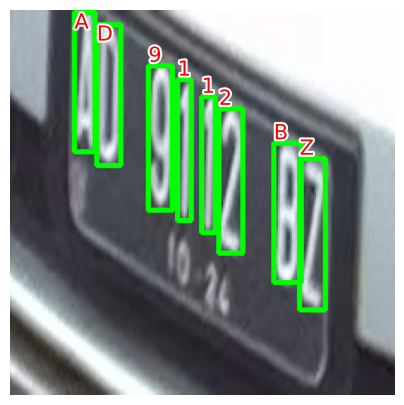

In [13]:
# Get the first image and target from the train set.
img, target = train_ds[10]
# Display the image and target.
show(
    img.cpu().permute(1, 2, 0).numpy(),
    bbs=target["boxes"].numpy(),
    texts=np.array(
        [reverse_label_dict[i] for i in target["labels"].numpy()]
    ),
    sz=5,
    text_sz=15,
)

## Model

In [14]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN


def get_object_detection_model(num_classes=3, feature_extraction=True):
    """
    Inputs
        num_classes: int
            Number of classes to predict. Must include the
            background which is class 0 by definition!
        feature_extraction: bool
            Flag indicating whether to freeze the pre-trained
            weights. If set to True the pre-trained weights will be
            frozen and not be updated during.
    Returns
        model: FasterRCNN
    """
    # Load the pretrained faster r-cnn model.
    model = fasterrcnn_resnet50_fpn(weight=True)
    # If True, the pre-trained weights will be frozen.
    if feature_extraction == True:
        for p in model.parameters():
            p.requires_grad = False
    # Replace the original 91 class top layer with a new layer
    # tailored for num_classes.
    in_feats = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feats, num_classes)
    return model

In [15]:
def unbatch(batch, device):
    """
    Unbatches a batch of data from the Dataloader.
    Inputs
        batch: tuple
            Tuple containing a batch from the Dataloader.
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        X: list
            List of images.
        y: list
            List of dictionaries.
    """
    X, y = batch
    X = [x.to(device) for x in X]
    y = [{k: v.to(device) for k, v in t.items()} for t in y]
    return X, y


def train_batch(batch, model: FasterRCNN, optimizer, device):
    """
    Uses back propagation to train a model.
    Inputs
        batch: tuple
            Tuple containing a batch from the Dataloader.
        model: torch model
        optimizer: torch optimizer
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        loss: float
            Sum of the batch losses.
        losses: dict
            Dictionary containing the individual losses.
    """
    model.train()
    X, y = unbatch(batch, device=device)
    optimizer.zero_grad()
    losses = model(X, y)
    loss = sum(loss for loss in losses.values())
    loss.backward()
    optimizer.step()
    return loss, losses


@torch.no_grad()
def validate_batch(batch, model, optimizer, device):
    """
    Evaluates a model's loss value using validation data.
    Inputs
        batch: tuple
            Tuple containing a batch from the Dataloader.
        model: torch model
        optimizer: torch optimizer
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        loss: float
            Sum of the batch losses.
        losses: dict
            Dictionary containing the individual losses.
    """
    model.train()
    X, y = unbatch(batch, device=device)
    optimizer.zero_grad()
    losses = model(X, y)
    loss = sum(loss for loss in losses.values())
    return loss, losses

In [16]:
def train_fasterrcnn(
        model: FasterRCNN,
        optimizer,
        n_epochs,
        train_loader,
        test_loader=None,
        log=None,
        keys=None,
        device="cpu",
):
    """
    Trains a FasterRCNN model using train and validation
    Dataloaders over n_epochs.
    Returns a Report on the training and validation losses.
    Inputs
        model: FasterRCNN
        optimizer: torch optimizer
        n_epochs: int
            Number of epochs to train.
        train_loader: DataLoader
        test_loader: DataLoader
        log: Record
            torch_snippet Record to record training progress.
        keys: list
            List of strs containing the FasterRCNN loss names.
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        log: Record
            torch_snippet Record containing the training records.
    """
    if log is None:
        log = Report(n_epochs)
    if keys is None:
        # FasterRCNN loss names.
        keys = [
            "loss_classifier",
            "loss_box_reg",
            "loss_objectness",
            "loss_rpn_box_reg",
        ]
    model.to(device)
    for epoch in range(n_epochs):
        N = len(train_loader)
        for ix, batch in enumerate(train_loader):
            # Train the model on the batch and record the losses.
            loss, losses = train_batch(batch, model, optimizer, device)
            loc_loss, regr_loss, loss_objectness, loss_rpn_box_reg = [
                losses[k] for k in keys
            ]
            # Record the current train loss.
            pos = epoch + (ix + 1) / N
            log.record(
                pos=pos,
                trn_loss=loss.item(),
                trn_loc_loss=loc_loss.item(),
                trn_regr_loss=regr_loss.item(),
                trn_objectness_loss=loss_objectness.item(),
                trn_rpn_box_reg_loss=loss_rpn_box_reg.item(),
                end="\r",
            )
        if test_loader is not None:
            N = len(test_loader)
            for ix, batch in enumerate(test_loader):
                # Evaluate the model on the batch and record the losses.
                loss, losses = validate_batch(batch, model, optimizer, device)
                loc_loss, regr_loss, loss_objectness, loss_rpn_box_reg = [
                    losses[k] for k in keys
                ]
                # Record the current validation loss.
                pos = epoch + (ix + 1) / N
                log.record(
                    pos=pos,
                    val_loss=loss.item(),
                    val_loc_loss=loc_loss.item(),
                    val_regr_loss=regr_loss.item(),
                    val_objectness_loss=loss_objectness.item(),
                    val_rpn_box_reg_loss=loss_rpn_box_reg.item(),
                    end="\r",
                )
    log.report_avgs(epoch + 1)
    return log

## Train Model

In [17]:
model = get_object_detection_model(
    num_classes=len(label_dict), feature_extraction=False
)
# Use the stochastic gradient descent optimizer.
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
log = train_fasterrcnn(
    model=model,
    optimizer=optimizer,
    n_epochs=5,
    train_loader=train_dl,
    test_loader=val_dl,
    log=None,
    keys=None,
    device=device,
)

EPOCH: 5.000  trn_loc_loss: 0.538  val_regr_loss: 0.382  val_objectness_loss: 0.044  trn_objectness_loss: 0.040  val_rpn_box_reg_loss: 0.150  trn_rpn_box_reg_loss: 0.165  val_loss: 1.153  trn_loss: 1.111  trn_regr_loss: 0.367  val_loc_loss: 0.578  (1378.85s - 0.00s remaining)


In [18]:
# Save the model.
torch.save(model.state_dict(), f"{MODEL_DIR}/model2.pth")

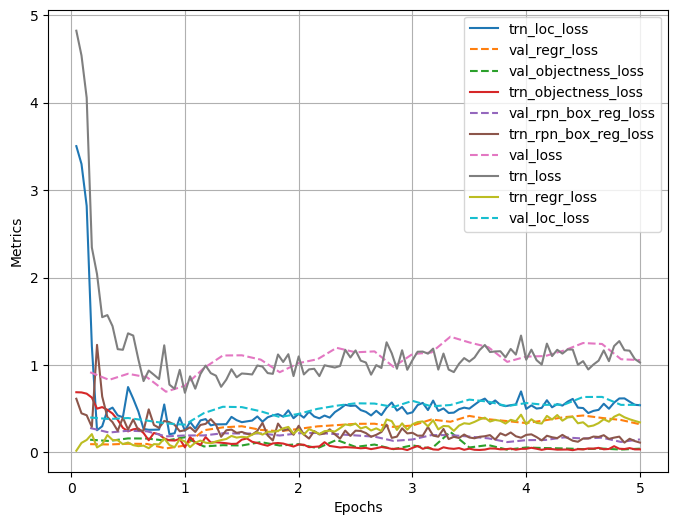

In [19]:
log.plot()

## Predictions

In [20]:
@torch.no_grad()
def predict_batch(batch, model, device):
    """
    Gets the predictions for a batch of data.
    Inputs
        batch: tuple
            Tuple containing a batch from the Dataloader.
        model: torch model
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        images: list
            List of tensors of the images.
        predictions: list
            List of dicts containing the predictions for the
            bounding boxes, labels and confidence scores.
    """
    model.to(device)
    model.eval()
    X, _ = unbatch(batch, device=device)
    predictions = model(X)
    return [x.cpu() for x in X], predictions


def predict(model, data_loader, device="cpu"):
    """
    Gets the predictions for a batch of data.
    Inputs
        model: torch model
        data_loader: torch Dataloader
        device: str
            Indicates which device (CPU/GPU) to use.
    Returns
        images: list
            List of tensors of the images.
        predictions: list
            List of dicts containing the predictions for the
            bounding boxes, labels and confidence scores.
    """
    images = []
    predictions = []
    for i, batch in enumerate(data_loader):
        X, p = predict_batch(batch, model, device)
        images = images + X
        predictions = predictions + p

    return images, predictions

In [21]:
def decode_prediction(prediction, score_threshold=0.8, nms_iou_threshold=0.2):
    """
    Inputs
        prediction: dict
        score_threshold: float
        nms_iou_threshold: float
    Returns
        prediction: tuple
    """
    boxes = prediction["boxes"]
    scores = prediction["scores"]
    labels = prediction["labels"]
    # Remove any low-score predictions.
    if score_threshold is not None:
        want = scores > score_threshold
        boxes = boxes[want]
        scores = scores[want]
        labels = labels[want]
    # Remove any overlapping bounding boxes using NMS.
    if nms_iou_threshold is not None:
        want = torchvision.ops.nms(
            boxes=boxes, scores=scores, iou_threshold=nms_iou_threshold
        )
        boxes = boxes[want]
        scores = scores[want]
        labels = labels[want]
    return boxes.cpu().numpy(), labels.cpu().numpy(), scores.cpu().numpy()

In [22]:
images, predictions = predict(model, test_dl, device)

In [23]:
predictions

[{'boxes': tensor([[ 24.7252,  75.9423,  39.8817, 161.3869],
          [105.7323,  78.8618, 119.6852, 158.3469],
          [163.3492,  86.4460, 177.5268, 160.8797],
          [129.0415,  68.6912, 136.7099, 168.6843],
          [156.9629,  77.4139, 172.5674, 164.4301],
          [ 98.8667,  74.7712, 114.3489, 161.2363],
          [ 18.6899,  85.1294,  35.1061, 161.5245],
          [151.7447,  66.3680, 158.9182, 171.9393],
          [145.1006,  63.8410, 171.0870, 172.9732],
          [ 11.2272,  64.9638,  37.1687, 170.7695],
          [ 55.6235,  74.0978,  66.8604, 161.6489],
          [127.6850,  58.7490, 155.6599, 178.0605],
          [ 65.0330,  61.2006,  94.1039, 178.6306],
          [115.1262,  76.1410, 128.6171, 161.1020],
          [ 76.5724,  74.8714,  92.9996, 161.6003],
          [121.6869,  74.9513, 134.0225, 162.6581],
          [ 55.4004,  63.7236,  83.5708, 170.8912],
          [ 90.8429,  74.7559, 106.4065, 161.1324],
          [101.0241,  67.6102, 128.0582, 176.6441],
   

In [33]:
predictions[0]["labels"].cpu().detach().numpy()

array([12, 12, 12,  2, 12, 12, 12,  2, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12,  2,  2, 12, 12,  2,  2,  2, 12, 12, 12, 12,
       12, 12, 12, 12,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2, 12,  2,  2,  2,  2,  2,  2],
      dtype=int64)

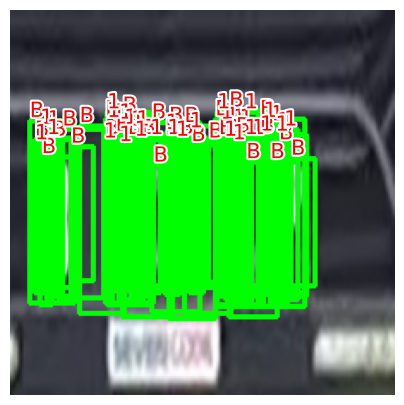

In [34]:
show(
    images[0].numpy(),
    bbs=predictions[0]["boxes"].cpu().detach().numpy(),
    texts=np.array(
        [reverse_label_dict[i] for i in predictions[0]["labels"].cpu().detach().numpy()]
    ),
    sz=5,
    text_sz=15,
)

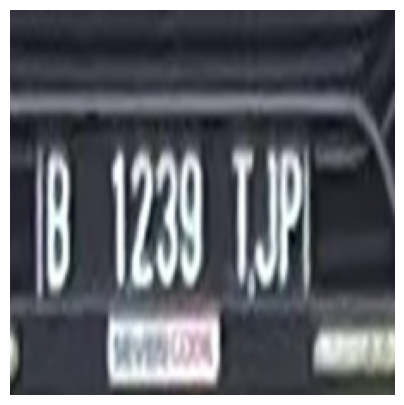

In [35]:
show(images[0].numpy())

In [24]:
def decode_output(output):
    'convert tensors to numpy arrays'
    bbs = output['boxes'].cpu().detach().numpy().astype(np.uint16)
    labels = np.array([reverse_label_dict[i] for i in output['labels'].cpu().detach().numpy()])
    confs = output['scores'].cpu().detach().numpy()
    ixs = torchvision.ops.nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
    bbs, confs, labels = [tensor[ixs] for tensor in [bbs, confs, labels]]

    if len(ixs) == 1:
        bbs, confs, labels = [np.array([tensor]) for tensor in [bbs, confs, labels]]
    return bbs.tolist(), confs.tolist(), labels.tolist()

In [25]:
def predict_image(model, data_loader, device="cpu"):
    model.eval()
    images, predictions = [], []
    for ix, (images, targets) in enumerate(data_loader):
        if ix == 3: break
        images = [im for im in images]
        outputs = model(images)
        for ix, output in enumerate(outputs):
            bbs, confs, labels = decode_output(output)
            show(images[ix].cpu().permute(1, 2, 0).numpy(), bbs=bbs, texts=labels, sz=5, text_sz=15)
            images.append(images[ix].cpu().permute(1, 2, 0).numpy())
            predictions.append({'boxes': bbs, 'labels': labels, 'scores': confs})
    return images, predictions

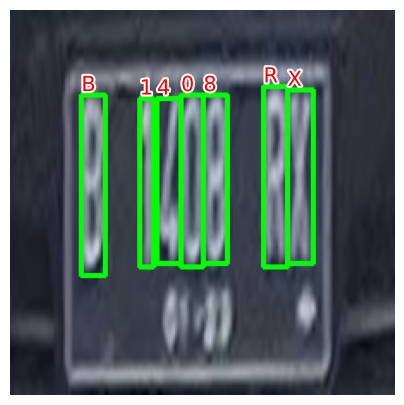

[] [] []


In [26]:
for i, test_batch in enumerate(test_dl):
    test_imgs, test_targets = test_batch
    img, target = test_imgs[0], test_targets[0]
    show(
        img.cpu().permute(1, 2, 0).numpy(),
        bbs=target["boxes"].numpy(),
        texts=np.array(
            [reverse_label_dict[i] for i in target["labels"].numpy()]
        ),
        sz=5,
        text_sz=15,
    )

    output = model([img.to(device)])
    bbs, confs, labels = decode_output(output[0])
    print(bbs, confs, labels)
    break


In [29]:
predictions

[{'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tensor([], device='cuda:0', dtype=torch.int64),
  'scores': tensor([], device='cuda:0')},
 {'boxes': tensor([], device='cuda:0', size=(0, 4)),
  'labels': tenso